# pzflow learned noise models

In this notebook we show how we can use the [pzflow package](https://jfcrenshaw.github.io/pzflow/) to  sample bandflux errors (uncertainties) from a photometric catalog. The pzflow model, as well as the input catalog data, are assumed to provide the standard deviation of the bandflux, while the noise itself is assumed to be Gaussian. The pzflow model samples bandflux errors conditionally to bandflux, passband and other relevant parameters from the `ObsTable`.

Note that the [pzflow package](https://jfcrenshaw.github.io/pzflow/) is not installed as part of the default LightCurveLynx installation. Users will need to manually install pzflow via pip (e.g. `pip install pzflow`) in order to run this notebook.

In [ ]:
import numpy as np
import pandas as pd
from pzflow import Flow

from lightcurvelynx.noise_models.pzflow_noise_model import PZFlowNoiseModel

## Training the PZFlow model

We start by generating a fake observational data set consisting of zero point and readout noise information.

In [2]:
num_training_samples = 10_000

# The input parameters for the pzflow model will be bandflux, zp, and readout_noise.
bandflux = np.random.normal(loc=500.0, scale=100.0, size=num_training_samples)
zp = np.random.normal(loc=10.0, scale=0.15, size=num_training_samples)
readout_noise = np.random.normal(loc=5.0, scale=1.0, size=num_training_samples)

source_variance = bandflux / zp
readout_variance = readout_noise**2  # Assume 1 exposure and psf_footprint = 1.

# This is the value the pzflow model is trained to predict.
flux_err = np.sqrt(source_variance + readout_variance) * zp

We can train a pzflow model based on this toy distribution by: 1) putting the data into a Pandas DataFrame, 2) creating a flow object that tells it which columns to model, and 3) using the `train` function.

In [3]:
training_data = pd.DataFrame(
    {
        "bandflux": bandflux,
        "zp": zp,
        "readout_noise": readout_noise,
        "flux_err": flux_err,
    }
)

flow = Flow(
    data_columns=["flux_err"],
    conditional_columns=["bandflux", "zp", "readout_noise"],
)

_ = flow.train(training_data, verbose=True)

# We can save the flow to an output file (which is how we generated the
# flow used in the tests).
# from lightcurvelynx import _LIGHTCURVELYNX_TEST_DATA_DIR
# flow.save(_LIGHTCURVELYNX_TEST_DATA_DIR / "fake_noise_flow.pkl")

Training 100 epochs 
Loss:
(0) 3.6438
(1) 2.8191
(6) 0.7491
(11) 0.2237
(16) 0.5771
(21) 0.1657
(26) -0.3631
(31) -0.4936
(36) -0.6089
(41) -0.6820
(46) -0.4497
(51) -0.4297
(56) -0.7242
(61) -1.1614
(66) -0.3205
(71) -1.2878
(76) -0.7818
(81) -1.2895
(86) -1.3647
(91) -1.5626
(96) -1.3285
(100) -1.4046


The `Flow` object is now a model of the distribution. We can use it to define our noise model.

# Defining the noise model

We start by defining the `ObsTable` with the relevant information. Only the `zp` column and the `readout_noise` constant are needed for the noise computation, but we need a few other columns (`time`, `ra`, `dec`) for the `OpSim` class itself.

In [4]:
from lightcurvelynx.obstable.opsim import OpSim

data = pd.DataFrame(
    {
        "time": 60676.0 + np.arange(100),
        "ra": np.random.uniform(0, 360, size=100),
        "dec": np.random.uniform(-90, 90, size=100),
        "zp": np.random.normal(loc=10.0, scale=0.15, size=100),
    }
)
obs_table = OpSim(data, read_noise=4.5)

Next we create a `PZFlowNoiseModel` object. If the parameter names in the pzflow model do not match the column (or constant) names in the `ObsTable`, we could use the `input_col_map` to define a mapping. As an example, we map the pzflow parameter `readout_noise` to table's `read_noise` constant.

In [5]:
model = PZFlowNoiseModel(flow, input_col_map={"readout_noise": "read_noise"})

## Applying the noise model

Now that we have a noise model defined, we can apply it to the a new set of bandfluxes. The noise model's `apply_noise` function first uses the pzflow to sample the flur errors (standard deviation of the noise for each observation). Then it uses those sampled flux errors to add noise to the bandfluxes. Both the new bandfluxes and the errors are returned.

In [6]:
bandflux = np.linspace(400.0, 600.0, 100)
indices = np.arange(100)
noisy_flux, flux_err = model.apply_noise(bandflux, obs_table=obs_table, indices=indices)

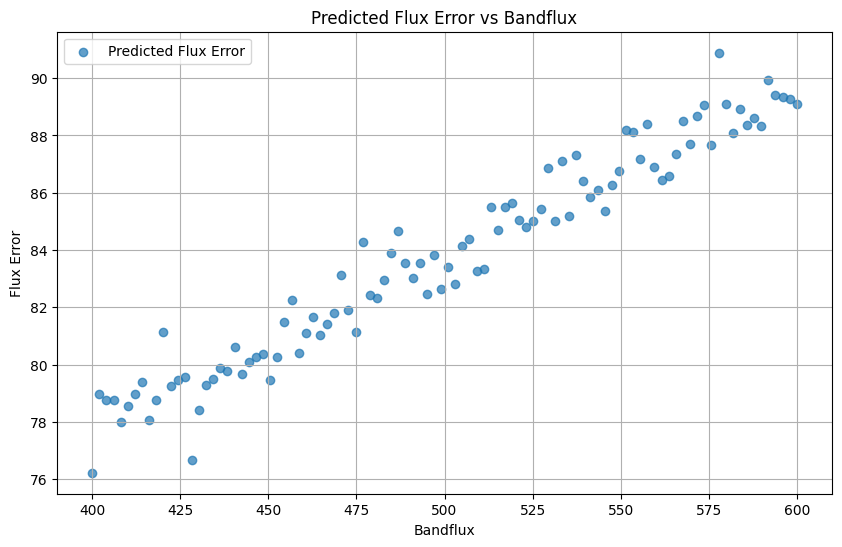

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(bandflux, flux_err, label="Predicted Flux Error", alpha=0.7)
plt.xlabel("Bandflux")
plt.ylabel("Flux Error")
plt.title("Predicted Flux Error vs Bandflux")
plt.legend()
plt.grid()
plt.show()

## Conclusion

The `PZFlowNoiseModel` object can be used like any other noise model during simulation.